In [2]:
import sys
!{sys.executable} -m pip install mysql-connector-python
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Pathanaksa29@",
    database="student_db"
)

print("✅ Connected Again")

✅ Connected Again


In [4]:
query = "SELECT * FROM Students"
df_students = pd.read_sql(query, conn)
df_students

C:\Users\ashwi\AppData\Local\Temp\ipykernel_10168\3636408484.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_students = pd.read_sql(query, conn)


,student_id,name,age,course,city
0,1,Aksa,21,BCA,Sangamner
1,2,Pathan,22,BCA,Maharashtra
2,3,Muzam,20,BBA,Mumbai
3,4,Priya,21,BCA,Nasik
4,5,Karan,23,BBA,Pune
5,6,rekha,22,BCA,manipur
6,7,Rohit,21,BBA,Delhi
7,8,Anjali,20,BCA,Jaipur
8,9,Vikas,24,BBA,Lucknow
9,10,Neha,21,BCA,Dehradun


C:\Users\ashwi\AppData\Local\Temp\ipykernel_10168\304113510.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top = pd.read_sql(query, conn)


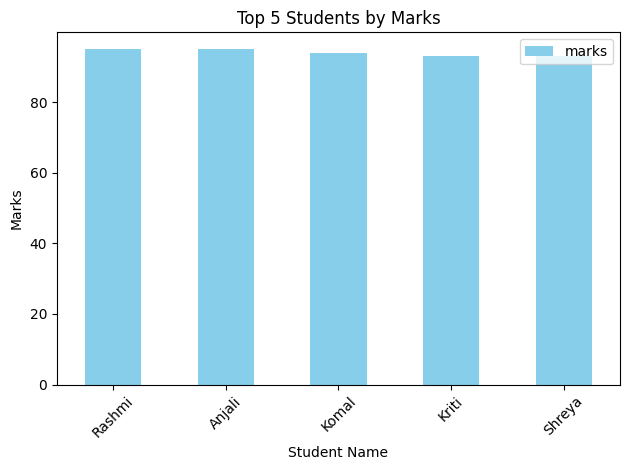

In [5]:
query = """
SELECT s.name, c.course_name, m.marks
FROM Students s
JOIN Marks m ON s.student_id = m.student_id
JOIN Courses c ON m.course_id = c.course_id
ORDER BY m.marks DESC
LIMIT 5
"""
df_top = pd.read_sql(query, conn)
df_top.plot(kind='bar', x='name', y='marks', color='skyblue')
plt.title('Top 5 Students by Marks')
plt.xlabel('Student Name')
plt.ylabel('Marks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ashwi\AppData\Local\Temp\ipykernel_10168\602243712.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_low = pd.read_sql(query, conn)


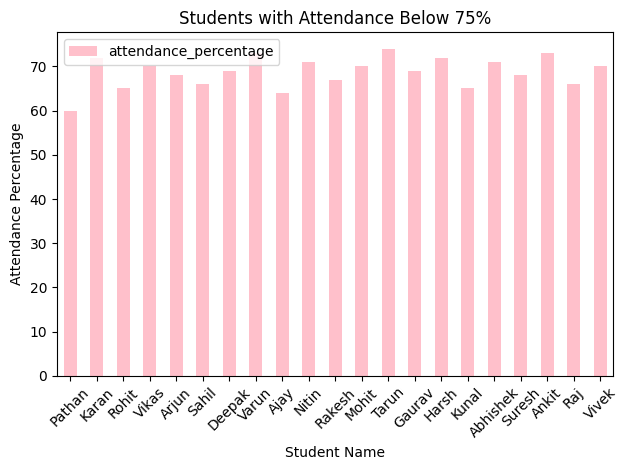

In [6]:
query = """
SELECT s.name, a.attendance_percentage
FROM Students s
JOIN Attendance a ON s.student_id = a.student_id
WHERE a.attendance_percentage < 75
"""

df_low = pd.read_sql(query, conn)

df_low.plot(kind='bar', x='name', y='attendance_percentage', color='pink')
plt.title('Students with Attendance Below 75%') 
plt.xlabel('Student Name')
plt.ylabel('Attendance Percentage')         
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ashwi\AppData\Local\Temp\ipykernel_10168\420765761.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_avg = pd.read_sql(query, conn)


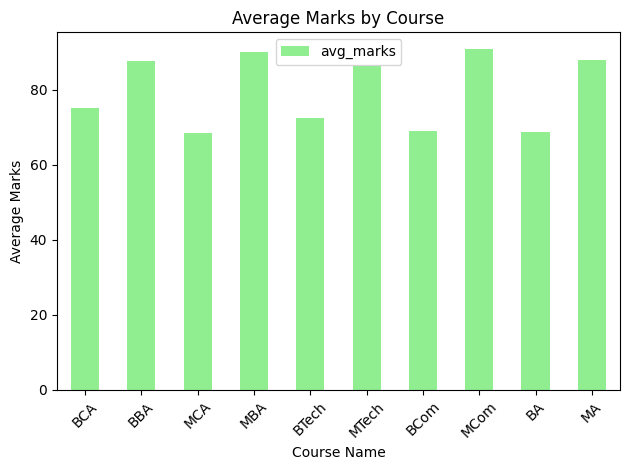

In [7]:
query = """
SELECT c.course_name, AVG(m.marks) AS avg_marks
FROM Marks m
JOIN Courses c ON m.course_id = c.course_id
GROUP BY c.course_name
"""
df_avg = pd.read_sql(query, conn)
df_avg.plot(kind='bar', x='course_name', y='avg_marks', color='lightgreen')
plt.title('Average Marks by Course')    
plt.xlabel('Course Name')
plt.ylabel('Average Marks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

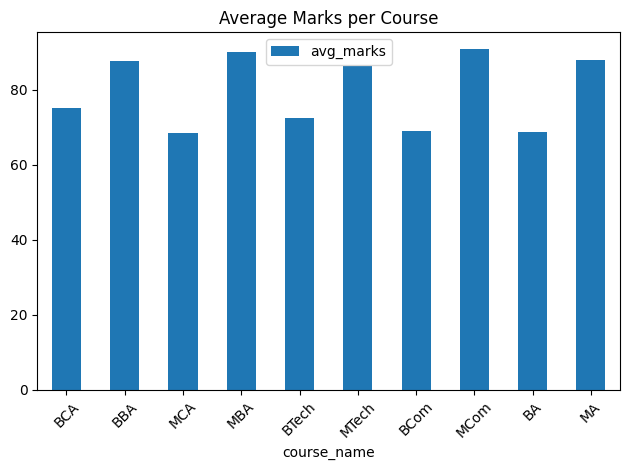

In [8]:
plt.figure()
df_avg.plot(x='course_name', y='avg_marks', kind='bar')
plt.title("Average Marks per Course")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
query = """
SELECT s.name, a.attendance_percentage
FROM Students s
JOIN Attendance a ON s.student_id = a.student_id
"""

df = pd.read_sql(query, conn)
print(df)

        name  attendance_percentage
0       Aksa                     85
1     Pathan                     60
2      Muzam                     78
3      Priya                     90
4      Karan                     72
5      rekha                     88
6      Rohit                     65
7     Anjali                     92
8      Vikas                     70
9       Neha                     80
10     Arjun                     68
11     Pooja                     95
12     Sahil                     66
13     Kriti                     89
14    Manish                     75
15     Sneha                     82
16    Deepak                     69
17      Riya                     91
18     Varun                     73
19     Meena                     87
20      Ajay                     64
21     Kajal                     93
22     Nitin                     71
23      Tina                     85
24      Yash                     76
25     Komal                     90
26    Rakesh                

C:\Users\ashwi\AppData\Local\Temp\ipykernel_10168\3355512212.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [10]:
conn.close()
print("Connection Closed")

Connection Closed
